# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

### Métrique de référence

F1 macro = 0.5018302920210277
ROC-AU = 0.7296295949589181
accuracy = 0.8491666666666666

### Features utilisées

Features numériques (des nombres) :
loan_amnt: montant emprunté
int_rate: taux d’intérêt
installment: mensualité
annual_inc: revenu annuel
dti: ratio dette/revenu
delinq_2yrs: incidents de paiement sur 2 ans
fico_range_low: niveau de score crédit (borne basse)
revol_util: utilisation du crédit renouvelable
=> Ces variables donnent une idée de la capacité à rembourser et du risque financier.

Features catégorielles (des catégories/texte) :
term: durée du prêt (36 mois, 60 mois…)
grade: note de risque du dossier
home_ownership: situation logement
verification_status: revenus vérifiés ou non
purpose: objectif du prêt
emp_length: ancienneté professionnelle
=> Ces catégories capturent des profils de risque différents, même sans être des nombres.

Cible à prédire :
loan_status
Fully Paid = 0 (pas défaut)
Charged Off = 1 (défaut)
Le but du modèle: prédire 0 ou 1.


### Architecture du modèle

Le modèle fonctionne en deux étapes : d’abord un prétraitement des données, puis une Random Forest. 
Les variables numériques sont complétées par la médiane puis standardisées. 
Les variables catégorielles sont complétées par la catégorie la plus fréquente puis transformées en variables 0/1. 
Ensuite, une Random Forest combine plusieurs arbres de décision pour prédire si le prêt sera remboursé ou en défaut.

## 2. EDA du nouveau dataset

Au moins 3 visualisations + un paragraphe sur ce qui diffère du dataset 2017.

In [8]:
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv')
df.shape, df.head(3)

((24000, 15),
    loan_amnt       term  int_rate  installment grade emp_length  \
 0       5700  36 months      6.71       175.24     A    3 years   
 1       8700  36 months     11.83       288.26     C    3 years   
 2       7900  36 months     11.25       259.57     C    5 years   
 
   home_ownership  annual_inc verification_status             purpose    dti  \
 0       MORTGAGE       38900        Not Verified      small_business  17.92   
 1           RENT       51400            Verified    home_improvement  21.26   
 2           RENT       38900            Verified  debt_consolidation  13.56   
 
    delinq_2yrs  fico_range_low  revol_util loan_status  
 0            0             738        78.1  Fully Paid  
 1            0             696        75.5  Fully Paid  
 2            0             696         8.1  Fully Paid  )

### Vérification du schéma vs baseline + qualité des données

Objectif EDA :
- comparer le schéma du dataset courant au schéma attendu par `pyrenex_risk_v1`
- identifier valeurs manquantes et anomalies
- vérifier la présence des variables sensibles (`fico_range_low`, `annual_inc`, `addr_state`, `emp_length`)

In [9]:
# Schéma baseline (repris de src/train_v1.py)
BASELINE_NUMERIC = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util'
]
BASELINE_CATEGORICAL = [
    'term', 'grade', 'home_ownership', 'verification_status',
    'purpose', 'emp_length'
]
BASELINE_TARGET = 'loan_status'
BASELINE_FEATURES = BASELINE_NUMERIC + BASELINE_CATEGORICAL

print('Shape dataset courant :', df.shape)
print('Colonnes totales :', len(df.columns))

missing_vs_baseline = sorted(set(BASELINE_FEATURES + [BASELINE_TARGET]) - set(df.columns))
extra_vs_baseline = sorted(set(df.columns) - set(BASELINE_FEATURES + [BASELINE_TARGET]))

print('\nColonnes baseline manquantes dans le dataset courant :', missing_vs_baseline)
print('Nb colonnes supplémentaires vs baseline :', len(extra_vs_baseline))
print('Exemples colonnes supplémentaires :', extra_vs_baseline[:10])

# Valeurs manquantes
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]

print('\nTop 15 colonnes avec valeurs manquantes :')
display(missing_report.head(15))

# Variables sensibles à surveiller
sensitive_vars = ['fico_range_low', 'annual_inc', 'addr_state', 'emp_length']
sensitive_presence = pd.Series({col: col in df.columns for col in sensitive_vars}, name='present')
print('\nPrésence des variables sensibles :')
display(sensitive_presence.to_frame())

if 'addr_state' in df.columns:
    print('Nombre d\'états US distincts (addr_state) :', df['addr_state'].nunique(dropna=True))
if 'emp_length' in df.columns:
    print('Modalités emp_length :', sorted(df['emp_length'].dropna().astype(str).unique())[:12], '...')

# Détection simple d'anomalies sur quelques variables clés
anomaly_checks = {}
if 'annual_inc' in df.columns:
    anomaly_checks['annual_inc<=0'] = int((df['annual_inc'] <= 0).sum())
if 'dti' in df.columns:
    anomaly_checks['dti<0'] = int((df['dti'] < 0).sum())
if 'fico_range_low' in df.columns:
    anomaly_checks['fico_outside_300_850'] = int(((df['fico_range_low'] < 300) | (df['fico_range_low'] > 850)).sum())

print('\nAnomalies (règles simples) :')
print(anomaly_checks)

Shape dataset courant : (24000, 15)
Colonnes totales : 15

Colonnes baseline manquantes dans le dataset courant : []
Nb colonnes supplémentaires vs baseline : 0
Exemples colonnes supplémentaires : []

Top 15 colonnes avec valeurs manquantes :


,missing_count,missing_pct
emp_length,953,3.97
revol_util,391,1.63



Présence des variables sensibles :


,present
fico_range_low,True
annual_inc,True
addr_state,False
emp_length,True


Modalités emp_length : ['1 year', '10+ years', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '< 1 year'] ...

Anomalies (règles simples) :
{'annual_inc<=0': 0, 'dti<0': 0, 'fico_outside_300_850': 0}


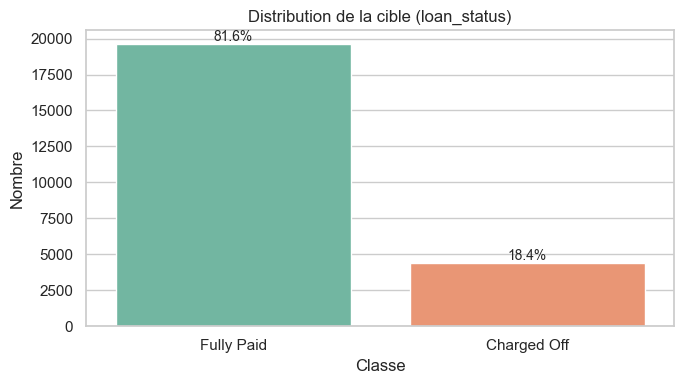

Taux de défaut (Charged Off): 18.39%


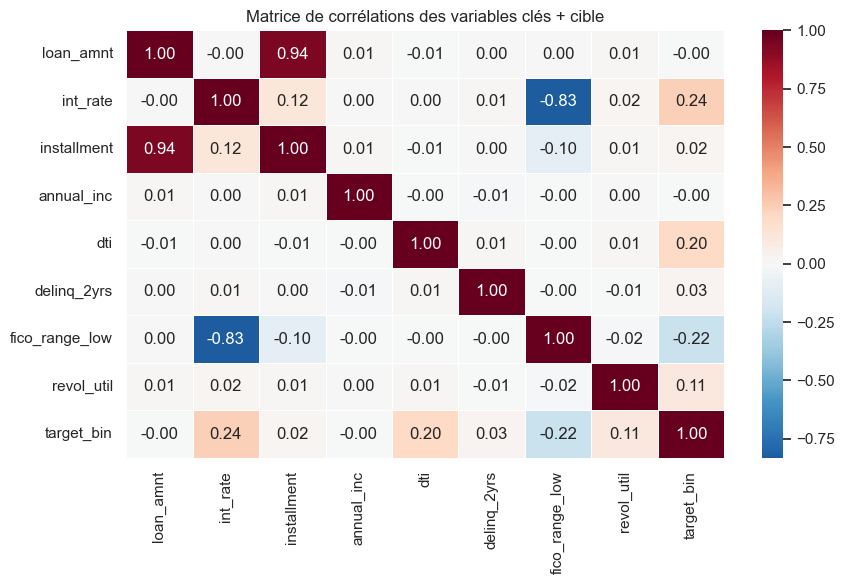

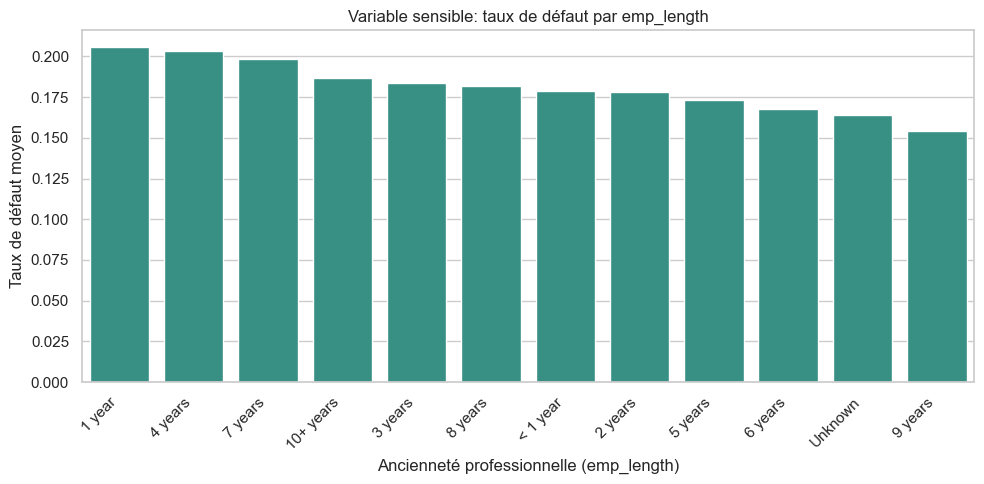

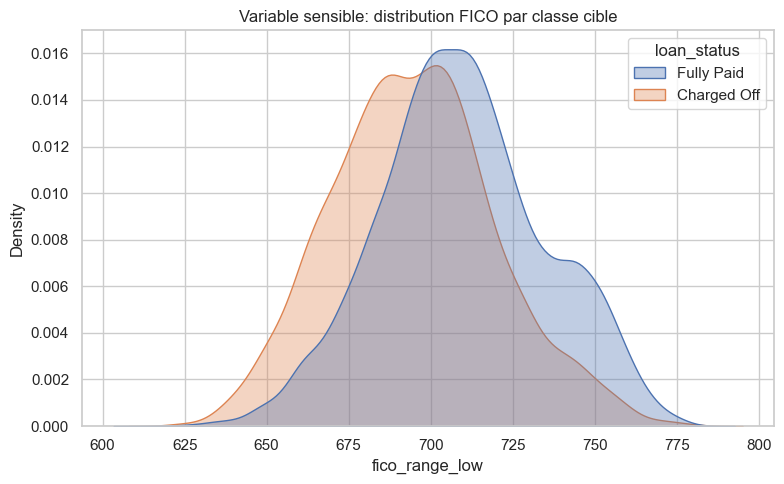

In [10]:
# Préparation cible binaire pour les visuels
TARGET_MAPPING = {'Fully Paid': 0, 'Charged Off': 1}

if BASELINE_TARGET in df.columns:
    df_plot = df.copy()
    df_plot['target_bin'] = df_plot[BASELINE_TARGET].map(TARGET_MAPPING)
else:
    raise ValueError(f'Colonne cible introuvable: {BASELINE_TARGET}')

sns.set_theme(style='whitegrid', context='notebook')

# VISU 1 - Distribution de la cible (déséquilibre des classes)
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_plot, x=BASELINE_TARGET, hue=BASELINE_TARGET, palette='Set2', legend=False)
total = len(df_plot)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h/total:.1%}', (p.get_x() + p.get_width()/2, h), ha='center', va='bottom', fontsize=10)
plt.title('Distribution de la cible (loan_status)')
plt.xlabel('Classe')
plt.ylabel('Nombre')
plt.tight_layout()
plt.show()

print('Taux de défaut (Charged Off):', f"{(df_plot['target_bin'] == 1).mean():.2%}")

# VISU 2 - Corrélations clés numériques (avec cible binaire)
corr_cols = [c for c in ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util', 'target_bin'] if c in df_plot.columns]
corr_mat = df_plot[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Matrice de corrélations des variables clés + cible')
plt.tight_layout()
plt.show()

# VISU 3 - Variable sensible: emp_length vs taux de défaut
if 'emp_length' in df_plot.columns:
    emp_default = (
        df_plot.assign(emp_length=df_plot['emp_length'].fillna('Unknown').astype(str))
        .groupby('emp_length', as_index=False)['target_bin']
        .mean()
        .sort_values('target_bin', ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(data=emp_default, x='emp_length', y='target_bin', color='#2a9d8f')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Taux de défaut moyen')
    plt.xlabel('Ancienneté professionnelle (emp_length)')
    plt.title('Variable sensible: taux de défaut par emp_length')
    plt.tight_layout()
    plt.show()

# Bonus sensible - FICO vs cible
if 'fico_range_low' in df_plot.columns:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df_plot, x='fico_range_low', hue=BASELINE_TARGET, fill=True, common_norm=False, alpha=0.35)
    plt.title('Variable sensible: distribution FICO par classe cible')
    plt.xlabel('fico_range_low')
    plt.tight_layout()
    plt.show()

### Synthèse EDA (vs baseline 2017)

- **Schéma** : le dataset courant est **aligné** avec le schéma baseline (0 colonne manquante, 0 extra).
- **Valeurs manquantes** : `emp_length` (~3.97%) et `revol_util` (~1.63%) sont à imputer.
- **Déséquilibre des classes** : la classe `Charged Off` représente ~**18.4%** (contre ~14.8% dans la baseline 2017), donc déséquilibre présent et plus marqué côté défaut.
- **Anomalies simples** : aucune anomalie détectée sur les règles testées (`annual_inc<=0`, `dti<0`, FICO hors [300, 850]).
- **Variables sensibles** :
  - présentes : `fico_range_low`, `annual_inc`, `emp_length`
  - absente : `addr_state` (pas de signal géographique état US exploitable dans ce dataset)
- **Signaux visuels clés** :
  - FICO plus faible pour les dossiers en défaut (distribution décalée à gauche)
  - relation positive de `int_rate` et `dti` avec la probabilité de défaut
  - variation du taux de défaut selon `emp_length` (effet profil socio-pro potentiellement sensible).

## 3. Préparation et split

Split stratifié, `random_state=42`.

In [13]:
# Section 3 - Préparation et split (train uniquement, sans holdout)
import sys
from pathlib import Path

from sklearn.model_selection import train_test_split

SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from preprocess import build_preprocessor, load_dataset

X, y = load_dataset(DATA_DIR / 'lending_club_train.csv')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print('Shapes:')
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

print('\nTaux de défaut (global / train / test):')
print(f"global={y.mean():.4f} | train={y_train.mean():.4f} | test={y_test.mean():.4f}")

# Reproduction des transformations baseline, sans fuite: fit sur train uniquement.
preprocessor = build_preprocessor()
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print('\nAprès preprocessing:')
print('X_train_prepared:', X_train_prepared.shape)
print('X_test_prepared :', X_test_prepared.shape)

Shapes:
X_train: (19200, 14) | X_test: (4800, 14)
y_train: (19200,) | y_test: (4800,)

Taux de défaut (global / train / test):
global=0.1839 | train=0.1839 | test=0.1840

Après preprocessing:
X_train_prepared: (19200, 43)
X_test_prepared : (4800, 43)


## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# TODO : adapte aux noms de tes variables (X, y, et le modèle de la section 4)
scores = []
for seed in [0, 1, 42, 100, 2024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    model = ...  # ré-instancie le même modèle qu'en section 4
    model.fit(X_tr, y_tr)
    f1 = f1_score(y_te, model.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.3f}")

print(f"\nÉcart min-max : {max(scores) - min(scores):.3f}")

**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.